# Bandwidth search

To find out the optimal bandwidth, `spatialml` provides a `BandwidthSearch` class, which trains models on a range of bandwidths and selects the most optimal one.

In [1]:
import geopandas as gpd
from geodatasets import get_path

from spatialml.linear_model import GWLinearRegression, GWLogisticRegression
from spatialml.search import BandwidthSearch

Get sample data

In [36]:
gdf = gpd.read_file(get_path("geoda.south")).to_crs(5070)

gdf["point"] = gdf.representative_point()
gdf = gdf.set_geometry("point")

y = gdf["FH90"]
X = gdf.iloc[:, 9:15]

## Interval search

Interval search tests the model at a set interval. The default and recommended criterion for linear models is corrected Akaike's information criterion (AICc).

In [37]:
search = BandwidthSearch(
    GWLinearRegression,
    fixed=False,
    n_jobs=-1,
    search_method="interval",
    min_bandwidth=50,
    max_bandwidth=1000,
    interval=100,
    criterion="aicc",
    verbose=True,
)
search.fit(
    X,
    y,
    geometry=gdf.geometry,
)

Bandwidth: 50.00, aicc: 7685.453
Bandwidth: 150.00, aicc: 7598.040
Bandwidth: 250.00, aicc: 7672.563
Bandwidth: 350.00, aicc: 7722.884
Bandwidth: 450.00, aicc: 7764.566
Bandwidth: 550.00, aicc: 7811.208
Bandwidth: 650.00, aicc: 7862.718
Bandwidth: 750.00, aicc: 7904.325
Bandwidth: 850.00, aicc: 7941.803
Bandwidth: 950.00, aicc: 7981.327


The `scores_` series then contains the AICc, selected as the criterion, which can be plotted to see the change of the model performance as the bandwidth grows.

<Axes: >

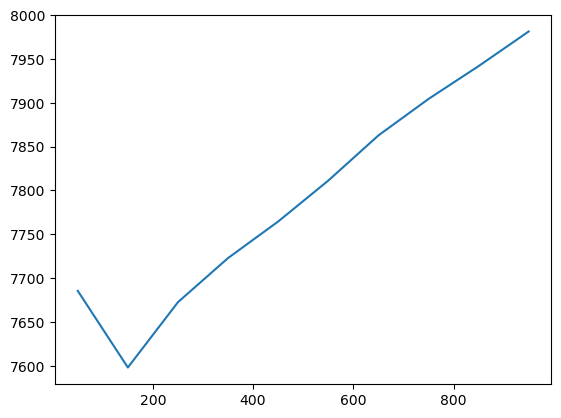

In [38]:
search.scores_.plot()

The optimal bandwidth is then the lowest one.

In [39]:
search.optimal_bandwidth_

np.int64(150)

## Golden section

Alternatively, you can try to use the golden section algorithm that attempts to find the optimal bandwidth iteratively. However, note that there's no guaratnee that it will find the globally optimal bandwidth as it may stick to the local minimum.

In [40]:
search = BandwidthSearch(
    GWLinearRegression,
    fixed=True,
    n_jobs=-1,
    search_method="golden_section",
    criterion="aicc",
    min_bandwidth=10_000,
    max_bandwidth=1_000_000,
    verbose=True,
)
search.fit(
    X,
    y,
    geometry=gdf.geometry,
)

Bandwidth: 388150.3, score: 7669.800
Bandwidth: 621849.7, score: 7770.467
Bandwidth: 243708.23, score: 7595.916
Bandwidth: 154442.07, score: 7909.632
Bandwidth: 298880.77, score: 7625.628
Bandwidth: 209613.32, score: 7615.954
Bandwidth: 264783.28, score: 7604.069
Bandwidth: 230686.59, score: 7596.427
Bandwidth: 251759.37, score: 7598.529
Bandwidth: 238735.76, score: 7595.231
Bandwidth: 235660.47, score: 7595.389
Bandwidth: 240634.23, score: 7595.329
Bandwidth: 237560.29, score: 7595.268
Bandwidth: 239460.08, score: 7595.241


You can see how the agorithm searches and iteratively gets closer to the optimum.

In [42]:
search.optimal_bandwidth_

np.float64(238735.7582789531)

## Other metrics

By default, `BandwidthSearch` computes AICc, AIC and BIC for linear models, available through `metrics_`.

In [43]:
search.metrics_

,aicc,aic,bic
388150.300000,7669.800284,7650.730706,8238.208833
621849.700000,7770.467076,7766.321405,8047.693794
243708.229909,7595.915658,7497.313206,8762.156146
154442.070091,7909.631563,7355.237895,9995.188728
298880.767422,7625.628201,7578.766844,8477.096909
209613.319310,7615.953544,7443.545102,9065.985674
264783.280267,7604.069091,7531.986411,8628.488146
230686.589297,7596.426806,7475.433826,8862.323769
251759.367217,7598.528817,7511.192286,8708.266105
238735.758279,7595.231162,7488.668425,8798.649792


You can also ask for a log loss and even use it as a criterion for the selection. This is useful when comparing classification models with varying prediction rate (you can also retrieve that for each bandwidth) or when using non-linear models, where MAE or RMSE should be used instead of AICc.

In [44]:
search = BandwidthSearch(
    GWLogisticRegression,
    fixed=False,
    n_jobs=-1,
    search_method="interval",
    min_bandwidth=50,
    max_bandwidth=1000,
    interval=200,
    metrics=["log_loss", "prediction_rate"],
    criterion="log_loss",
    verbose=True,
)
search.fit(
    X,
    y > y.median(),  # simulate binary categorical variable
    geometry=gdf.geometry,
)

Bandwidth: 50.00, log_loss: 0.276
Bandwidth: 250.00, log_loss: 0.376
Bandwidth: 450.00, log_loss: 0.413
Bandwidth: 650.00, log_loss: 0.437
Bandwidth: 850.00, log_loss: 0.454


Log loss is then part of the metrics.

In [45]:
search.metrics_

,aicc,aic,bic,log_loss,prediction_rate
50,1376.806548,1119.216534,2551.160957,0.275782,0.682011
250,1262.969346,1249.800971,1741.819969,0.376227,1.000000
450,1275.319005,1271.315792,1547.948404,0.412885,1.000000
650,1308.172651,1306.304157,1497.258268,0.436826,1.000000
850,1337.777857,1336.720382,1481.487638,0.453824,1.000000


And is reported directly as score as it is set as the criterion.

<Axes: >

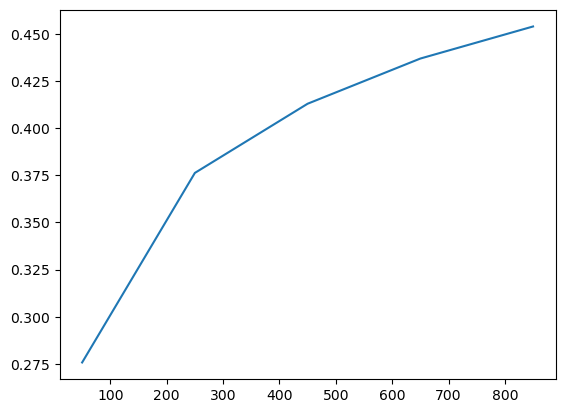

In [46]:
search.scores_.plot()

As a result, the optimal bandwidth is derived directly from it.

In [47]:
search.optimal_bandwidth_

np.int64(50)